# 두 Worker로 만드는 VOC 주간 보고서

VOC(Voice of Customer, 고객의 소리)는 고객이 문의·불만·요청으로 남긴 업무 데이터이다. 고객센터에서는 문의 건수뿐 아니라 반복되는 문제, 해결 속도와 미해결 위험을 함께 살펴야 다음 조치를 정할 수 있다.

Multi-Agent는 하나의 모델에게 모든 일을 맡기지 않고 역할이 다른 Agent들을 연결해 하나의 작업을 완성하는 방식이다. 이번 실습에서는 다음 두 Worker만 사용한다.

- 분석 Worker: 로컬 CSV의 KPI Tool을 호출해 운영 상태와 주요 VOC를 해석한다.
- 작성 Worker: 분석 결과를 정해진 보고서 항목으로 바꾼다.

`create_agent()`는 각 Worker 내부의 모델 호출·Tool loop·구조화 출력을 조립한다. `StateGraph`는 두 Worker와 저장 단계를 어떤 순서로 실행할지 연결한다. 즉, `create_agent()`는 **Worker 내부**, `StateGraph`는 **Worker 사이의 흐름**을 담당한다.

```text
support_tickets.csv
        ↓
분석 Worker ── KPI Tool 호출
        ↓ analysis
작성 Worker ── 정성 문장 구조화
        ↓ report_sections
저장 Node ── 정확한 KPI 표 결합
        ↓
Markdown + PDF
```

이번 실습은 고정된 순서가 필요한 업무이므로 Router, Supervisor, Conditional Edge와 재작성 loop를 사용하지 않는다.


## 실습 패키지 설치

LangChain은 `create_agent()`를, LangGraph는 Worker 간 실행 순서를, pandas는 CSV 집계를 담당한다. Pydantic은 작성 Worker의 출력 항목과 자료형을 검증하고, Matplotlib은 완성된 Markdown 내용을 읽을 수 있는 PDF로 저장한다.

설치 셀은 현재 Jupyter kernel의 패키지를 준비할 뿐 모델이나 Tool을 실행하지 않는다.


In [21]:
from langchain_openai import ChatOpenAI
%pip install -U langchain langchain-openai langgraph pandas pydantic matplotlib python-dotenv


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## OpenAI 실행 환경 준비

In [22]:
import os
from dotenv import find_dotenv, load_dotenv

dotenv_path = find_dotenv(usecwd=True)
if dotenv_path:
    load_dotenv(dotenv_path, override=False)

required_env_vars = ["OPENAI_API_KEY"]
missing_env_vars = [name for name in required_env_vars if not os.getenv(name)]
if missing_env_vars:
    raise RuntimeError(
        "다음 필수 환경 변수가 없거나 비어 있다: " + ", ".join(missing_env_vars)
    )

OPENAI_CHAT_MODEL = os.getenv("OPENAI_CHAT_MODEL", "gpt-5.6-luna")
print("필수 API 환경 변수 이름과 수업용 모델 ID를 확인했다.")


필수 API 환경 변수 이름과 수업용 모델 ID를 확인했다.


## 로컬 VOC CSV 읽기

 한 행은 고객 문의 한 건이고, `category`·`priority`·`status`는 집계 기준이며 `summary`는 분석 Worker가 이해할 문제 설명이다.

`data/support_tickets.csv`는 노트북 폴더를 기준으로 한 상대 경로이다. 표에서 15개 문의와 8개 열이 준비되는지 확인한다.


In [23]:
from pathlib import Path

import pandas as pd

DATA_PATH = Path("data/support_tickets.csv")
tickets_df = pd.read_csv(DATA_PATH)

EXPECTED_COLUMNS = [
    "ticket_id",
    "received_date",
    "category",
    "priority",
    "status",
    "resolution_hours",
    "satisfaction",
    "summary",
]

assert tickets_df.columns.tolist() == EXPECTED_COLUMNS
assert len(tickets_df) == 15
assert set(tickets_df["status"]) == {"resolved", "open"}
assert set(tickets_df["priority"]) == {"high", "medium", "low"}
assert tickets_df.loc[
    tickets_df["status"].eq("resolved"), "resolution_hours"
].notna().all()

tickets_df


,ticket_id,received_date,category,priority,status,resolution_hours,satisfaction,summary
0,T001,2026-08-10,결제,high,resolved,6.0,5.0,중복 결제 후 즉시 취소 요청
1,T002,2026-08-10,로그인,medium,resolved,8.0,4.0,비밀번호 재설정 메일 도착 지연
2,T003,2026-08-11,배송,medium,resolved,30.0,3.0,배송 조회 상태가 이틀 동안 갱신되지 않음
3,T004,2026-08-11,결제,high,open,NaN,NaN,모바일 결제 단계에서 반복 오류
4,T005,2026-08-12,로그인,low,resolved,10.0,4.0,소셜 로그인 후 첫 화면으로 반복 이동
5,T006,2026-08-12,결제,medium,resolved,28.0,3.0,할인 쿠폰이 결제 금액에 반영되지 않음
6,T007,2026-08-13,배송,high,open,NaN,NaN,출고 완료 후 배송 위치 확인 불가
7,T008,2026-08-13,로그인,medium,resolved,6.0,5.0,휴면 해제 후 로그인이 차단됨
8,T009,2026-08-14,환불,high,resolved,16.0,4.0,부분 환불 금액 확인 요청
9,T010,2026-08-14,결제,low,resolved,12.0,5.0,현금영수증 발급 내역 누락


## pandas로 KPI를 결정적으로 계산하기

KPI(Key Performance Indicator, 핵심 성과 지표)는 운영 상태를 판단하기 위해 정한 수치이다. 이 실습에서는 LLM이 수치를 계산하지 않고 pandas 함수가 다음 값을 만든다.

- 해결률: 전체 문의 중 `resolved` 문의의 비율이다.
- 평균 해결 시간: 해결된 문의의 `resolution_hours` 평균이다.
- SLA(Service Level Agreement, 서비스 수준 약속) 초과율: 해결 시간이 24시간을 **초과한** 문의의 비율이다. 정확히 24시간인 문의는 초과에서 제외한다.
- 평균 만족도: 값이 기록된 `satisfaction`의 평균이다.

계산 결과를 `EXPECTED_METRICS`와 비교해 Tool과 LLM을 연결하기 전에 데이터 기준선을 고정한다.


In [24]:

def calculate_support_metrics(df: pd.DataFrame) -> dict:
    '''VOC DataFrame을 결정적인 KPI와 미해결 사례 딕셔너리로 집계한다.'''
    resolved_df = df.loc[df["status"].eq("resolved")].copy()
    open_df = df.loc[df["status"].eq("open")].copy()
    sla_violation_count = int(resolved_df["resolution_hours"].gt(24).sum())
    category_counts = {
        category: int(count)
        for category, count in df["category"].value_counts().items()
    }

    # 계산된 KPI 수치와 미해결 사례를 하나의 dict 반환
    return {
        "period": f"{df['received_date'].min()} ~ {df['received_date'].max()}",
        "total_tickets": int(len(df)),
        "resolved_tickets": int(len(resolved_df)),
        "open_tickets": int(len(open_df)),
        "resolved_rate_pct": round(len(resolved_df) / len(df) * 100, 1),
        "avg_resolution_hours": round(float(resolved_df["resolution_hours"].mean()), 1),
        "sla_violation_count": sla_violation_count,
        "sla_violation_rate_pct": round(sla_violation_count / len(resolved_df) * 100, 1),
        "avg_satisfaction": round(float(df["satisfaction"].dropna().mean()), 1),
        "high_priority_open": int(
            (open_df["priority"].eq("high")).sum()
        ),
        "category_counts": category_counts,
        "open_examples": open_df[
            ["ticket_id", "category", "priority", "summary"]
        ].to_dict("records"),
    }


## KPI 기준값 대조하기

`support_metrics`는 Tool, Writer와 저장 Node가 함께 사용할 단일 수치 원본이다. `EXPECTED_METRICS`는 수업용 CSV의 정답이며, `assert`는 계산 결과가 기준값과 하나라도 다르면 즉시 실행을 멈춘다.

이 검사를 먼저 통과시켜야 이후 보고서의 수치 오류를 Agent 문제가 아니라 데이터·집계 문제로 분리할 수 있다.


In [25]:
support_metrics = calculate_support_metrics(tickets_df)

EXPECTED_METRICS = {
    "period": "2026-08-10 ~ 2026-08-16",
    "total_tickets": 15,
    "resolved_tickets": 12,
    "open_tickets": 3,
    "resolved_rate_pct": 80.0,
    "avg_resolution_hours": 15.0,
    "sla_violation_count": 3,
    "sla_violation_rate_pct": 25.0,
    "avg_satisfaction": 4.0,
    "high_priority_open": 2,
    "category_counts": {"결제": 6, "로그인": 4, "배송": 3, "환불": 2},
    "open_examples": [
        {"ticket_id": "T004", "category": "결제", "priority": "high", "summary": "모바일 결제 단계에서 반복 오류"},
        {"ticket_id": "T007", "category": "배송", "priority": "high", "summary": "출고 완료 후 배송 위치 확인 불가"},
        {"ticket_id": "T011", "category": "배송", "priority": "medium", "summary": "배송지 변경 요청이 주문에 반영되지 않음"},
    ],
}
assert support_metrics == EXPECTED_METRICS
support_metrics


{'period': '2026-08-10 ~ 2026-08-16',
 'total_tickets': 15,
 'resolved_tickets': 12,
 'open_tickets': 3,
 'resolved_rate_pct': 80.0,
 'avg_resolution_hours': 15.0,
 'sla_violation_count': 3,
 'sla_violation_rate_pct': 25.0,
 'avg_satisfaction': 4.0,
 'high_priority_open': 2,
 'category_counts': {'결제': 6, '로그인': 4, '배송': 3, '환불': 2},
 'open_examples': [{'ticket_id': 'T004',
   'category': '결제',
   'priority': 'high',
   'summary': '모바일 결제 단계에서 반복 오류'},
  {'ticket_id': 'T007',
   'category': '배송',
   'priority': 'high',
   'summary': '출고 완료 후 배송 위치 확인 불가'},
  {'ticket_id': 'T011',
   'category': '배송',
   'priority': 'medium',
   'summary': '배송지 변경 요청이 주문에 반영되지 않음'}]}

## 작성 결과와 Graph State의 자료형 정의

`ReportSections`는 작성 Worker가 만들 정성 문장의 구조이다. `summary`는 한 문단이고, `voc_insights`와 `actions`는 각각 세 항목으로 제한한다.

`ReportState`는 Worker 사이에 전달할 업무 값을 이름 있는 field로 정의한다. `total=False`는 최초 입력에 `request`만 넣고 각 Node가 나머지 field를 순서대로 추가할 수 있게 한다.


In [26]:
from typing import TypedDict

from pydantic import BaseModel, Field

# ReportSections: LLM의 답변 양식
class ReportSections(BaseModel):
    summary: str = Field(description="숫자 없이 작성한 주간 운영 요약 한 문단")
    voc_insights: list[str] = Field(
        min_length=3,
        max_length=3,
        description="숫자 없이 작성한 주요 VOC 해석 세 항목",
    )
    actions: list[str] = Field(
        min_length=3,
        max_length=3,
        description="숫자 없이 작성한 다음 주 권장 조치 세 항목",
    )

# Node가 읽고 dict 형태로 공유할
class ReportState(TypedDict, total=False):
    request: str
    metrics: dict
    analysis: str
    analyst_message_types: list[str]
    report_sections: ReportSections
    report_markdown: str
    markdown_path: str
    pdf_path: str


## KPI 함수를 분석 Worker의 Tool로 제공하기

`@tool`은 Python 함수의 이름·docstring·type hint를 모델이 읽을 수 있는 Tool schema로 바꾼다. `get_support_metrics()`는 인자를 받지 않고 앞에서 검증한 `support_metrics`를 사람이 읽을 수 있는 근거 문자열로 반환한다.

분석 Worker는 원본 CSV를 직접 추측하지 않고 이 Tool을 호출해 KPI와 미해결 사례를 얻는다. 같은 `support_metrics`는 뒤의 저장 Node가 정확한 KPI 표를 만들 때도 재사용한다.


In [27]:
from langchain_core.tools import tool

def format_metrics_evidence(metrics: dict) -> str:
    '''KPI 딕셔너리를 분석 Worker가 읽을 고정 근거 문자열로 변환한다.'''
    category_text = ", ".join(
        f"{name} {count}건"
        for name, count in metrics["category_counts"].items()
    )
    open_text = "\n".join(
        f"- {item['ticket_id']} | {item['category']} | {item['priority']} | {item['summary']}"
        for item in metrics["open_examples"]
    )
    return (
        f"기간: {metrics['period']}\n"
        f"전체 문의: {metrics['total_tickets']}건\n"
        f"해결: {metrics['resolved_tickets']}건, 미해결: {metrics['open_tickets']}건\n"
        f"해결률: {metrics['resolved_rate_pct']}%\n"
        f"평균 해결 시간: {metrics['avg_resolution_hours']}시간\n"
        f"SLA 초과: {metrics['sla_violation_count']}건 ({metrics['sla_violation_rate_pct']}%)\n"
        f"평균 만족도: {metrics['avg_satisfaction']} / 5.0\n"
        f"high 우선순위 미해결: {metrics['high_priority_open']}건\n"
        f"카테고리별 문의: {category_text}\n"
        f"미해결 사례:\n{open_text}"
    )


## 분석 Worker가 호출할 Tool 등록하기

`@tool`은 formatter를 모델이 선택할 수 있는 `get_support_metrics` Tool로 감싼다. 이 Tool은 인자를 받지 않으며, 호출할 때마다 이미 검증한 `support_metrics`를 같은 형식으로 반환한다.

먼저 `invoke({})`로 독립 실행해 반환 문자열을 확인한 뒤 Agent에 연결한다.


In [28]:

@tool
def get_support_metrics() -> str:
    '''현재 주간 고객센터 KPI와 미해결 VOC 근거를 반환한다.'''

    # csv -> dict(KPI + 미해결 VOC) -> str(KPI + 미해결 VOC)
    return format_metrics_evidence(support_metrics)


print(get_support_metrics.invoke({}))

기간: 2026-08-10 ~ 2026-08-16
전체 문의: 15건
해결: 12건, 미해결: 3건
해결률: 80.0%
평균 해결 시간: 15.0시간
SLA 초과: 3건 (25.0%)
평균 만족도: 4.0 / 5.0
high 우선순위 미해결: 2건
카테고리별 문의: 결제 6건, 로그인 4건, 배송 3건, 환불 2건
미해결 사례:
- T004 | 결제 | high | 모바일 결제 단계에서 반복 오류
- T007 | 배송 | high | 출고 완료 후 배송 위치 확인 불가
- T011 | 배송 | medium | 배송지 변경 요청이 주문에 반영되지 않음


## 두 Worker의 역할 정책 준비

같은 모델을 사용해도 system prompt와 연결된 기능이 다르면 Worker의 역할이 달라진다.

- 분석 Worker는 `get_support_metrics`를 반드시 호출하고 Tool 결과에 근거한 운영 해석만 만든다.
- 작성 Worker는 Tool을 사용하지 않고 분석 결과를 `ReportSections` 구조로 정리한다. 숫자와 티켓 ID는 뒤의 결정적 저장 코드가 넣으므로 정성 문장만 작성한다.

In [29]:
ANALYST_SYSTEM_PROMPT = '''
너는 고객센터 운영 분석 Worker이다.
보고서 요청을 받으면 반드시 get_support_metrics Tool을 호출한다.
Tool 결과만 근거로 운영 상태, 반복 VOC와 미해결 위험을 짧게 분석한다.
Tool에 없는 수치나 사실을 만들지 않는다.
'''.strip()

WRITER_SYSTEM_PROMPT = '''
너는 고객센터 주간 보고서 작성 Worker이다.
입력으로 받은 분석만 사용해 ReportSections를 완성한다.
summary는 한 문단, voc_insights와 actions는 각각 세 항목으로 작성한다.
정확한 KPI와 티켓 ID는 저장 코드가 따로 넣으므로 아라비아 숫자를 쓰지 않는다.
'''.strip()


## 같은 모델을 두 역할로 나누는 방법

두 Worker는 같은 Chat Model을 공유하지만, 연결된 기능과 역할 정책이 다르다. 분석 Worker는 검증된 KPI Tool을 사용할 수 있고, 작성 Worker는 Tool 없이 정해진 보고서 구조만 만든다.

```mermaid
flowchart LR
    MODEL["공유 Chat Model"] --> ANALYST["분석 Worker"]
    KPI["검증된 KPI Tool"] --> ANALYST
    AP["분석 역할 정책"] --> ANALYST

    MODEL --> WRITER["작성 Worker"]
    WP["작성 역할 정책"] --> WRITER
    SCHEMA["ReportSections 출력 계약"] --> WRITER
```


## 1단계: 분석 Worker와 작성 Worker 생성하기

`ChatOpenAI` 객체 하나를 두 Worker가 공유한다. `create_agent()`는 Worker 내부 실행 방식을 다음처럼 다르게 조립한다.

- `analyst_agent`: `tools=[get_support_metrics]`와 `ANALYST_SYSTEM_PROMPT`를 전달한다.
- `writer_agent`: `tools=[]`, `WRITER_SYSTEM_PROMPT`, `response_format=ReportSections`를 전달한다.

작성 Worker는 Tool이 없으므로 한 번의 구조화된 모델 응답으로 종료된다. 이 셀은 Worker 객체만 만들며 실제 OpenAI 호출은 뒤의 Graph 실행 셀에서 발생한다.


In [30]:
from langchain_openai import ChatOpenAI
from langchain.agents import create_agent

# LLM 모델 생성
model = ChatOpenAI(
    model_name=OPENAI_CHAT_MODEL,
    use_responses_api=True
)

# 분석용 Worker Agent
analyst_agent = create_agent(
    model = model,
    tools = [get_support_metrics],
    system_prompt = ANALYST_SYSTEM_PROMPT,
)

# 보고서 작성용 Worker Agent
writer_agent = create_agent(
    model = model,
    tools = [],
    system_prompt = WRITER_SYSTEM_PROMPT,

    # model의 응답 형식을 지정
    response_format = ReportSections,
)

## 분석 Worker 반환값을 State update로 바꾸는 helper

분석 Worker의 반환 `messages`에는 사용자 요청, Tool 요청, `ToolMessage`, 최종 `AIMessage`가 들어간다. `extract_analyst_update()`는 학생이 message 순회에 매몰되지 않도록 다음 작업을 대신한다.

1. `get_support_metrics`의 `ToolMessage`가 있는지 확인한다.
2. 마지막 `AIMessage.text`를 `analysis` 문자열로 꺼낸다.
3. 정확한 `support_metrics`와 message type 목록을 State update 딕셔너리로 반환한다.


In [31]:
from langchain_core.messages import ToolMessage

def extract_analyst_update(agent_result: dict) -> dict:
    '''분석 Agent State에서 Tool 사용 증거와 최종 텍스트를 추출한다.'''
    messages = agent_result["messages"]
    metric_tool_messages = [
        message
        for message in messages
        if isinstance(message, ToolMessage)
        and message.name == "get_support_metrics"
    ]
    if not metric_tool_messages:
        raise RuntimeError("분석 Worker가 get_support_metrics Tool을 호출하지 않았다.")

    analysis_text = str(messages[-1].text).strip()

    return {
        "metrics": support_metrics,
        "analysis": analysis_text, # 분석 결과
        "analyst_message_types": [type(message).__name__ for message in messages],
    }


## Agent 내부 결과가 ReportState로 바뀌는 흐름

Agent가 만든 전체 message 기록을 상위 Graph에 그대로 넘기지 않는다. Node adapter가 다음 단계에 필요한 업무 값만 골라 부분 State로 반환한다.

```mermaid
flowchart LR
    REQ["ReportState · request"] --> AN["분석 Node adapter"]
    AN --> AA["분석 Worker · Tool loop"]
    KPI["support_metrics · pandas 결정값"] --> TOOL["KPI Tool"]
    AA -->|"Tool 요청"| TOOL
    TOOL -->|"ToolMessage 근거"| AA
    AA -->|"최종 분석 message"| AN
    AN -->|"metrics · analysis · message types"| STATE["갱신된 ReportState"]
    STATE --> WN["작성 Node adapter"]
    WN --> WA["작성 Worker"]
    WA -->|"ReportSections"| WN
    WN -->|"report_sections"| NEXT["다시 갱신된 ReportState"]
```

`analysis`는 작성 Worker의 입력이 되고, `report_sections`는 뒤의 저장 Node가 읽는다. 이 그림은 입력 → 변환 → 출력 → 다음 사용처만 보여 주며 반환 딕셔너리 문법은 제시하지 않는다.


## 2단계: 두 Worker를 StateGraph Node로 감싸기

LangGraph Node는 State를 입력받고 변경할 field만 부분 딕셔너리로 반환한다.

- `analyst_node(state)`: `state["request"]`를 분석 Worker의 user message로 전달하고 `extract_analyst_update()` 결과를 반환한다.
- `writer_node(state)`: `state["analysis"]`를 작성 Worker에 전달하고 `structured_response`를 `report_sections`에 저장한다.

두 함수는 Worker를 새로 만들지 않는다. 앞 셀에서 생성한 Agent를 호출해 상위 Graph가 사용할 입력·출력 형태로 바꾸는 adapter이다.


In [32]:
def analyst_node(state:ReportState) -> dict:
    # 사용자가 전달한 VOC 분석 요청
    analyst_result = analyst_agent.invoke({
            "messages": [{
                "role":"user",
                "content": state["request"]
            }]
        })

    # helper를 이용해서 analyst_agent 분석 결과를
    # {metrics, analysis(llm 분석 결과), message type} 형태로 반환
    return extract_analyst_update(analyst_result)


def writer_node(state:ReportState) -> dict:
    writer_result = writer_agent.invoke({
        "messages": [{
            "role": "user",
            "content": (
                '다음 분석을 고객센터 주간 보고서의 '
                '정성 영역으로 작성한다. \n\n'
                f"{state['analysis']}"
            )
        }]
    })

    # ReportSections 검증을 통과한 객체를 반환
    return {
        "report_sections": writer_result["structured_response"],
    }

## 정확한 KPI와 Writer 문장을 하나의 Markdown으로 결합하기

작성 Worker는 문장만 만들고 KPI 표와 미해결 티켓은 Python 코드가 `metrics`에서 직접 렌더링한다. 이 경계를 지키면 LLM이 수치를 바꾸더라도 최종 보고서의 공식 KPI는 결정적 계산값을 사용한다.

`render_report_markdown()`은 Writer 영역에 아라비아 숫자가 들어오면 저장을 중단한다. 숫자는 검증된 KPI 표와 미해결 사례에서만 나타나야 한다.


In [33]:
def render_kpi_table(metrics: dict) -> str:
    '''검증된 KPI 딕셔너리를 Markdown 표로 변환한다.'''
    category_text = " / ".join(
        f"{name} {count}건"
        for name, count in metrics["category_counts"].items()
    )
    return "\n".join(
        [
            "| 지표 | 값 |",
            "| --- | ---: |",
            f"| 기간 | {metrics['period']} |",
            f"| 전체 문의 | {metrics['total_tickets']}건 |",
            f"| 해결 / 미해결 | {metrics['resolved_tickets']}건 / {metrics['open_tickets']}건 |",
            f"| 해결률 | {metrics['resolved_rate_pct']}% |",
            f"| 평균 해결 시간 | {metrics['avg_resolution_hours']}시간 |",
            f"| SLA 초과 | {metrics['sla_violation_count']}건 / {metrics['sla_violation_rate_pct']}% |",
            f"| 평균 만족도 | {metrics['avg_satisfaction']} / 5.0 |",
            f"| high 우선순위 미해결 | {metrics['high_priority_open']}건 |",
            f"| 카테고리별 문의 | {category_text} |",
        ]
    )


## 정성 문장과 KPI 표 결합하기

`render_report_markdown()`은 `ReportSections`의 정성 문장과 앞에서 만든 KPI 표를 정해진 순서로 합친다. Writer 영역에 숫자가 들어오면 `ValueError`를 발생시켜 수치의 출처가 섞이지 않게 한다.

미해결 티켓 역시 LLM 문장이 아니라 `metrics["open_examples"]`에서 그대로 가져온다.


In [34]:
import re

def render_report_markdown(metrics: dict, sections: ReportSections) -> str:
    '''정확한 수치 영역과 LLM 정성 영역을 최종 보고서로 결합한다.'''
    narrative_text = " ".join(
        [sections.summary, *sections.voc_insights, *sections.actions]
    )
    if re.search(r"\d", narrative_text):
        raise ValueError("Writer의 정성 문장에 아라비아 숫자가 포함되어 있다.")

    open_case_lines = "\n".join(
        f"- `{item['ticket_id']}` {item['category']} · {item['priority']}: {item['summary']}"
        for item in metrics["open_examples"]
    )
    insight_lines = "\n".join(map("- {}".format, sections.voc_insights))
    action_lines = "\n".join(map("- {}".format, sections.actions))
    return (
        "# 고객센터 주간 VOC 보고서\n\n"
        "## 주간 운영 요약\n\n"
        f"{sections.summary}\n\n"
        "## 핵심 KPI\n\n"
        f"{render_kpi_table(metrics)}\n\n"
        "## 주요 VOC\n\n"
        "### 미해결 사례\n\n"
        f"{open_case_lines}\n\n"
        "### 분석 결과\n\n"
        f"{insight_lines}\n\n"
        "## 권장 조치\n\n"
        f"{action_lines}\n"
    )


## Markdown 내용을 읽을 수 있는 PDF로 변환하기

PDF 레이아웃은 Multi-Agent 학습 목표가 아니므로 완성 helper로 제공한다. `find_korean_font()`는 현재 운영체제에 설치된 대표 한글 font를 찾고, `save_markdown_pdf()`는 Markdown 기호를 단순화해 한 페이지 PDF로 저장한다.

고급 표 디자인이나 회사 양식 적용은 별도 문서 생성 단계에서 확장할 수 있다. 이번 실습의 통과 기준은 같은 보고서 내용을 읽을 수 있는 PDF 파일이 생성되는 것이다.


In [35]:
from matplotlib import font_manager

KOREAN_FONT_CANDIDATES = (
    Path("C:/Windows/Fonts/malgun.ttf"),
    Path("/System/Library/Fonts/Supplemental/AppleGothic.ttf"),
    Path("/usr/share/fonts/truetype/nanum/NanumGothic.ttf"),
    Path("/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc"),
)

def find_korean_font():
    '''Windows·macOS·Linux의 대표 한글 font 중 설치된 첫 font를 반환한다.'''
    font_path = next(
        (path for path in KOREAN_FONT_CANDIDATES if path.exists()),
        None,
    )
    if font_path is None:
        raise RuntimeError("한글 PDF 저장에 사용할 font를 찾지 못했다.")
    return font_manager.FontProperties(fname=font_path)


## 한 페이지 PDF 저장 함수 정의하기

`save_markdown_pdf()`는 Markdown 기호를 걷어 내고 긴 줄을 나눈 뒤 A4 크기 figure에 텍스트를 배치한다. 입력은 완성된 Markdown 문자열과 출력 `Path`이고, 반환값 없이 PDF 파일을 만든다.

보고서가 한 페이지 범위를 넘으면 자동으로 글자를 지나치게 줄이는 대신 오류를 발생시킨다.


In [36]:
from textwrap import wrap

import matplotlib.pyplot as plt

def save_markdown_pdf(markdown_text: str, output_path: Path) -> None:
    '''짧은 수업용 Markdown 보고서를 한 페이지 PDF로 저장한다.'''
    plain_lines = []
    for line in markdown_text.splitlines():
        cleaned = re.sub(r"^#{1,3}\s*", "", line)
        cleaned = re.sub(r"[*_`]", "", cleaned).replace("|", "   ").strip()
        cleaned = re.sub(r"^-{3,}\s+-{3,}:?$", "", cleaned)
        plain_lines.extend(wrap(cleaned, width=72) or [""])
    if len(plain_lines) > 58:
        raise ValueError("PDF 한 페이지에 넣기에는 보고서가 너무 길다.")

    figure = plt.figure(figsize=(8.27, 11.69), facecolor="white")
    figure.text(
        0.06,
        0.96,
        "\n".join(plain_lines),
        ha="left",
        va="top",
        fontsize=9,
        linespacing=1.35,
        fontproperties=find_korean_font(),
    )
    plt.axis("off")
    figure.savefig(output_path, format="pdf", bbox_inches="tight")
    plt.close(figure)


## 저장 Node로 Markdown과 PDF 만들기

`save_report_node()`는 Writer가 만든 `report_sections`와 분석 Node가 저장한 `metrics`를 받아 완성 보고서를 만든다. 출력 폴더는 CSV가 있는 수업 폴더 아래의 `outputs`이다.

Node는 파일을 저장한 뒤 `report_markdown`, `markdown_path`, `pdf_path`만 반환한다. 이 부분 딕셔너리는 기존 State와 합쳐져 마지막 검증 셀이 재사용한다.


In [37]:
def save_report_node(state: ReportState) -> dict:
    report_markdown = render_report_markdown(
        state["metrics"],
        state["report_sections"],
    )

    output_dir = DATA_PATH.parent.parent / "outputs"
    output_dir.mkdir(parents=True, exist_ok=True)
    markdown_path = output_dir / "voc_weekly_report.md"
    pdf_path = output_dir / "voc_weekly_report.pdf"

    markdown_path.write_text(report_markdown, encoding="utf-8")
    save_markdown_pdf(report_markdown, pdf_path)

    return {
        "report_markdown": report_markdown,
        "markdown_path": str(markdown_path),
        "pdf_path": str(pdf_path),
    }


## 수치와 문장이 보고서 파일로 합쳐지는 흐름

최종 보고서는 서로 다른 두 출처를 저장 단계에서 결합한다. KPI와 티켓 정보는 pandas 계산값에서 가져오고, LLM은 정성 문장만 만든다.

```mermaid
flowchart LR
    METRICS["ReportState.metrics · pandas 수치"] --> RENDER["보고서 결합"]
    SECTIONS["ReportState.report_sections · LLM 문장"] --> CHECK{"정성 문장에 숫자가 있는가?"}
    CHECK -->|"있음"| STOP["저장 중단"]
    CHECK -->|"없음"| RENDER
    RENDER --> REPORT["report_markdown"]
    REPORT --> SAVE["저장 Node"]
    SAVE --> MD["voc_weekly_report.md"]
    SAVE --> PDF["voc_weekly_report.pdf"]
```

이 경계 덕분에 자연어 표현은 모델이 담당하면서도 보고서의 공식 수치는 반복 계산 가능한 값으로 유지된다.


## 3단계: 두 Worker와 저장 Node를 고정 순서로 연결하기

`StateGraph(ReportState)`는 Node가 공유할 field 계약을 받는 builder이다. 이번 업무는 분석 결과가 있어야 작성할 수 있으므로 다음 고정 Edge를 사용한다.

```mermaid
flowchart LR
    START((START)) -->|"request"| ANALYST["analyst Node"]
    ANALYST -->|"metrics · analysis 추가"| WRITER["writer Node"]
    WRITER -->|"report_sections 추가"| SAVE["save Node"]
    SAVE -->|"보고서 · 파일 경로 추가"| END((END))
```

`add_node(name, callable)`로 세 함수를 등록하고, `add_edge(source, target)`로 네 경로를 연결한 뒤 `compile()`로 실행 가능한 `report_graph`를 만든다.


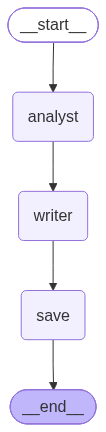

In [38]:
from langgraph.graph import START, END, StateGraph

report_builder = StateGraph(ReportState)

# 노드 추가
report_builder.add_node("analyst", analyst_node)
report_builder.add_node("writer" , writer_node)
report_builder.add_node("save"   , save_report_node)

# 엣지 추가 (Sequential)
report_builder.add_edge(START, "analyst")
report_builder.add_edge("analyst", "writer")
report_builder.add_edge("writer", "save")
report_builder.add_edge("save", END)

# 실행 가능한 상태로 변경
report_graph = report_builder.compile()
report_graph


## 컴파일된 Graph 구조 확인

앞 셀의 Mermaid는 완성할 실행 순서를 보여 주는 설계 힌트이다. `get_graph().draw_mermaid()`는 실제로 컴파일된 Node와 Edge를 Mermaid 문자열로 반환하므로 두 구조가 같은지 대조할 수 있다.

PNG 렌더링이나 외부 서비스 없이 `analyst → writer → save` 순서를 텍스트로 확인한다.


In [39]:
print(report_graph.get_graph().draw_mermaid())


---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	analyst(analyst)
	writer(writer)
	save(save)
	__end__([<p>__end__</p>]):::last
	__start__ --> analyst;
	analyst --> writer;
	writer --> save;
	save --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



```mermaid
---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	analyst(analyst)
	writer(writer)
	save(save)
	__end__([<p>__end__</p>]):::last
	__start__ --> analyst;
	analyst --> writer;
	writer --> save;
	save --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc

```

## VOC 보고서 Graph 실행

최초 State에는 자연어 `request` 하나만 넣는다. `invoke()`가 시작되면 분석 Worker가 KPI Tool을 호출하고, 작성 Worker가 정성 영역을 구조화한 뒤, 저장 Node가 Markdown과 PDF를 만든다.

이 셀부터 OpenAI 모델 호출과 로컬 파일 쓰기가 실제로 발생한다. 최종 출력에서는 Agent 내부 추론 전문 대신 분석 Worker의 message type, 보고서와 파일 경로만 확인한다.


In [40]:
from IPython.display import Markdown, display

initial_state = {
    "request": "이번 주 고객센터 VOC와 운영 KPI를 근거로 주간 보고서를 작성해 줘."
}

final_state = report_graph.invoke(initial_state)

print("분석 Worker message 유형:", final_state["analyst_message_types"])
print("Markdown:", final_state["markdown_path"])
print("PDF:", final_state["pdf_path"])
display(Markdown(final_state["report_markdown"]))


분석 Worker message 유형: ['HumanMessage', 'AIMessage', 'ToolMessage', 'AIMessage']
Markdown: outputs\voc_weekly_report.md
PDF: outputs\voc_weekly_report.pdf


# 고객센터 주간 VOC 보고서

## 주간 운영 요약

이번 주 고객센터는 전반적으로 문의 대응이 진행되었으나 일부 미해결 건과 SLA 초과가 발생해 처리 적시성 개선이 필요합니다. 특히 모바일 결제 오류와 배송 관련 이슈가 주요 위험으로 확인되었으며, 반복되는 결제 장애와 배송 추적·배송지 변경 반영 문제에 대한 우선 점검이 요구됩니다.

## 핵심 KPI

| 지표 | 값 |
| --- | ---: |
| 기간 | 2026-08-10 ~ 2026-08-16 |
| 전체 문의 | 15건 |
| 해결 / 미해결 | 12건 / 3건 |
| 해결률 | 80.0% |
| 평균 해결 시간 | 15.0시간 |
| SLA 초과 | 3건 / 25.0% |
| 평균 만족도 | 4.0 / 5.0 |
| high 우선순위 미해결 | 2건 |
| 카테고리별 문의 | 결제 6건 / 로그인 4건 / 배송 3건 / 환불 2건 |

## 주요 VOC

### 미해결 사례

- `T004` 결제 · high: 모바일 결제 단계에서 반복 오류
- `T007` 배송 · high: 출고 완료 후 배송 위치 확인 불가
- `T011` 배송 · medium: 배송지 변경 요청이 주문에 반영되지 않음

### 분석 결과

- 모바일 결제 단계에서 반복 오류가 발생해 결제 문의가 가장 많은 유형으로 나타났으며, 고객의 결제 완료를 방해하는 핵심 원인으로 확인되었습니다.
- 배송 관련 미해결 문의가 두 건 발생했으며, 출고 이후 배송 위치 확인 불가와 배송지 변경 미반영이 주요 불편 요인으로 나타났습니다.
- 미해결 건 중 높은 우선순위의 이슈가 두 건이고 SLA 초과도 발생해, 긴급 문의에 대한 초기 대응과 후속 관리 강화가 필요합니다.

## 권장 조치

- 모바일 결제 오류의 재현 조건과 발생 구간을 점검하고, 결제 모듈 및 오류 로그를 우선적으로 확인합니다.
- 배송 추적 정보 연계 상태와 배송지 변경 반영 절차를 점검해 관련 문의의 처리 기준과 고객 안내를 정비합니다.
- 미해결 및 SLA 초과 건을 우선순위에 따라 재분류하고, 담당자별 후속 일정과 고객 재안내 체계를 마련합니다.


## Tool 사용·KPI·파일 결과 검증

최종 답변 문장이 자연스러운지만 보면 Agent가 실제 Tool을 썼는지, KPI가 원본과 같은지 알 수 없다. 마지막 셀은 다음 네 조건을 코드로 확인한다.

- 분석 Worker의 message 유형에 `ToolMessage`가 있다.
- 최종 State의 `metrics`가 fresh pandas 계산값과 같다.
- 보고서에 네 필수 제목이 있다.
- Markdown과 PDF가 존재하며 PDF header가 올바르다.


In [42]:
required_headings = [
    "# 고객센터 주간 VOC 보고서",
    "## 주간 운영 요약",
    "## 핵심 KPI",
    "## 주요 VOC",
    "## 권장 조치",
]
markdown_path = Path(final_state["markdown_path"])
pdf_path = Path(final_state["pdf_path"])

assert "ToolMessage" in final_state["analyst_message_types"]
assert final_state["metrics"] == calculate_support_metrics(tickets_df)
assert all(
    heading in final_state["report_markdown"]
    for heading in required_headings
)
assert markdown_path.exists() and markdown_path.stat().st_size > 0
assert pdf_path.exists() and pdf_path.stat().st_size > 0
assert pdf_path.read_bytes()[:4] == b"%PDF"

print("검증 통과: ToolMessage, KPI, Markdown, PDF")


검증 통과: ToolMessage, KPI, Markdown, PDF


## 정리

이 실습에서 `create_agent()`는 분석·작성 Worker의 내부 동작을 만들고, `StateGraph`는 두 Worker와 저장 Node를 고정 순서로 연결한다. 수치 계산은 pandas와 Tool에 남기고 LLM은 해석과 문장 작성에만 사용하면 업무 자동화에서 근거와 생성 영역을 분리할 수 있다.

Supervisor나 재작성 loop는 Worker의 다음 행동을 동적으로 결정해야 할 때 추가한다. 순서가 이미 정해진 주간 보고서에는 단순 Sequential Graph가 더 읽기 쉽고 실행 비용도 예측하기 쉽다.
